### Task 1: Designing a Heuristic for a Warehouse Robot

In [1]:
import math
import heapq
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd


def draw_graph(graph, locations, path=None, title="", node_size=2400):
    G = nx.DiGraph()
    for node in locations:
        G.add_node(node)
    for node, neighbors in graph.items():
        for neighbor, cost in neighbors.items():
            G.add_edge(node, neighbor, weight=cost)
    pos = locations
    plt.figure(figsize=(12, 7))
    nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=node_size)
    nx.draw_networkx_edges(G, pos, edge_color="gray", width=1.5, arrows=True, arrowsize=22, node_size=node_size)
    if path:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_nodes(G, pos, nodelist=path, node_color="orange", node_size=node_size)
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color="red", width=4, arrows=True, arrowsize=26, node_size=node_size)
    nx.draw_networkx_labels(G, pos, font_size=8)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "weight"))
    plt.title(title)
    plt.axis("off")
    plt.show()


locations = {
    "Receiving_Area": (0, 0),
    "Storage_A": (2, 1),
    "Storage_B": (1, 4),
    "Sorting_Area": (4, 2),
    "Inspection_Area": (5, 5),
    "Packing_Station": (7, 6)
}

warehouse_graph = {
    "Receiving_Area": {"Storage_A": 2.2, "Storage_B": 4.1},
    "Storage_A": {"Sorting_Area": 2.2},
    "Storage_B": {"Inspection_Area": 5.0, "Sorting_Area": 6.0},
    "Sorting_Area": {"Inspection_Area": 3.2, "Packing_Station": 5.0},
    "Inspection_Area": {"Packing_Station": 2.2},
    "Packing_Station": {}
}


def heuristic(current, goal):
    x1, y1 = locations[current]
    x2, y2 = locations[goal]
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)


goal = "Packing_Station"

print("Heuristic Values")
print("----------------")

heuristic_table = []
for location in locations:
    h = heuristic(location, goal)
    heuristic_table.append({"Location": location, "Coordinates": locations[location], "h(n)": round(h, 3)})
    print(f"{location:18s} h = {h:.3f}")

pd.DataFrame(heuristic_table)

Heuristic Values
----------------
Receiving_Area     h = 9.220
Storage_A          h = 7.071
Storage_B          h = 6.325
Sorting_Area       h = 5.000
Inspection_Area    h = 2.236
Packing_Station    h = 0.000


,Location,Coordinates,h(n)
0,Receiving_Area,"(0, 0)",9.220
1,Storage_A,"(2, 1)",7.071
2,Storage_B,"(1, 4)",6.325
3,Sorting_Area,"(4, 2)",5.000
4,Inspection_Area,"(5, 5)",2.236
5,Packing_Station,"(7, 6)",0.000


#### NetworkX visualization: Since Task 1 does not ask GBFS/A* to find a path, the actual minimum-cost path is highlighted merely for visualization:

In [3]:
G = nx.DiGraph()

for node, neighbors in warehouse_graph.items():
    for neighbor, cost in neighbors.items():
        G.add_edge(node, neighbor, weight=cost)

solution_path = nx.shortest_path(
    G,
    source="Receiving_Area",
    target="Packing_Station",
    weight="weight"
)

solution_cost = nx.shortest_path_length(
    G,
    source="Receiving_Area",
    target="Packing_Station",
    weight="weight"
)

print("\nMinimum cost path:")
print(" -> ".join(solution_path))
print(f"Total cost: {solution_cost:.2f}")


Minimum cost path:
Receiving_Area -> Storage_A -> Sorting_Area -> Packing_Station
Total cost: 9.40


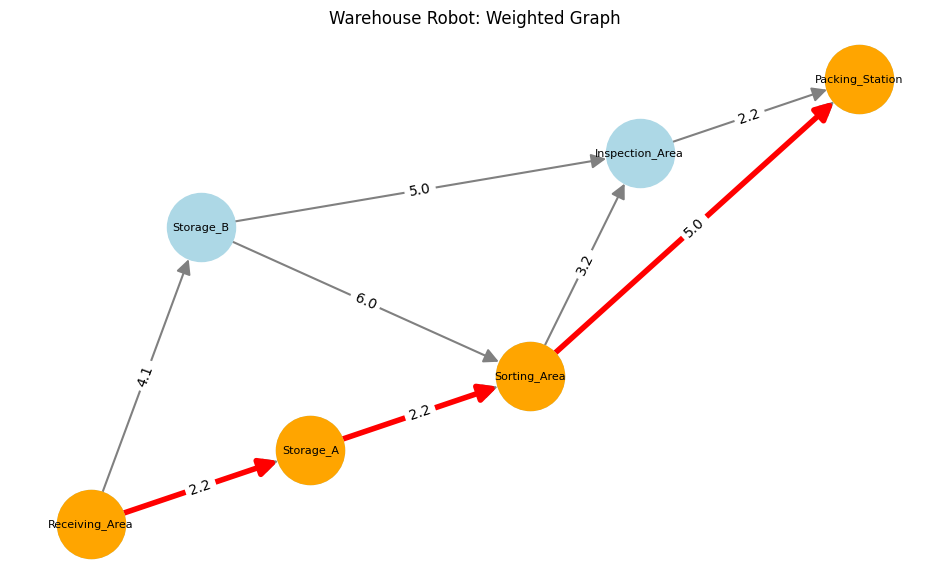

In [3]:
draw_graph(warehouse_graph, locations, solution_path, "Warehouse Robot: Weighted Graph")

In [4]:
print("\nHeuristic Condition Verification")
print("***********************************")

violations = []

for node in warehouse_graph:
    for neighbor, cost in warehouse_graph[node].items():
        lhs = heuristic(node, goal)
        rhs = cost + heuristic(neighbor, goal)
        ok = lhs <= rhs
        if not ok:
            violations.append((node, neighbor))
        print(f"h({node}) = {lhs:.3f}  <=  cost + h({neighbor}) = {rhs:.3f}  ->  {'OK' if ok else 'VIOLATED'}")

print("\nViolations:", violations if violations else "none")


Heuristic Condition Verification
***********************************
h(Receiving_Area) = 9.220  <=  cost + h(Storage_A) = 9.271  ->  OK
h(Receiving_Area) = 9.220  <=  cost + h(Storage_B) = 10.425  ->  OK
h(Storage_A) = 7.071  <=  cost + h(Sorting_Area) = 7.200  ->  OK
h(Storage_B) = 6.325  <=  cost + h(Inspection_Area) = 7.236  ->  OK
h(Storage_B) = 6.325  <=  cost + h(Sorting_Area) = 11.000  ->  OK
h(Sorting_Area) = 5.000  <=  cost + h(Inspection_Area) = 5.436  ->  OK
h(Sorting_Area) = 5.000  <=  cost + h(Packing_Station) = 5.000  ->  OK
h(Inspection_Area) = 2.236  <=  cost + h(Packing_Station) = 2.200  ->  VIOLATED

Violations: [('Inspection_Area', 'Packing_Station')]


**Why Euclidean distance is appropriate:** the locations have physical (x, y) coordinates, and the straight-line distance is the shortest possible way to travel between two points, so it can never overestimate the true remaining movement cost (admissible). It is also cheap to compute for every node.

**Observation:** Euclidean distance never overestimates the real cost, so it is admissible, but the check finds one edge that breaks consistency: Inspection_Area to Packing_Station has cost 2.2 while h(Inspection_Area) = 2.236, a violation of only 0.036 that comes from the rounded edge cost given in the task. All other edges satisfy h(n) <= cost(n,m) + h(m).

### Task 2: Greedy Best-First Search for Airport Baggage Handling

In [5]:
locations = {
    "Baggage_Area": (0, 0),
    "Security": (2, 1),
    "Checkpoint": (1, 4),
    "Food_Court": (4, 2),
    "Terminal_Hall": (5, 5),
    "Departure_Gate": (8, 6)
}

airport_graph = {
    "Baggage_Area": {"Security": 2.2, "Checkpoint": 4.1},
    "Security": {"Food_Court": 2.2},
    "Checkpoint": {"Terminal_Hall": 5.0},
    "Food_Court": {"Terminal_Hall": 3.2, "Departure_Gate": 6.0},
    "Terminal_Hall": {"Departure_Gate": 3.2},
    "Departure_Gate": {}
}


def heuristic(current, goal):
    x1, y1 = locations[current]
    x2, y2 = locations[goal]
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)


def greedy_best_first_search(start, goal, graph):
    frontier = [(heuristic(start, goal), start)]
    came_from = {}
    queued = {start}
    visited = set()
    expansion_order = []

    while frontier:
        _, current = heapq.heappop(frontier)
        if current in visited:
            continue
        visited.add(current)
        expansion_order.append(current)

        if current == goal:
            break

        for neighbor in graph[current]:
            if neighbor not in visited and neighbor not in queued:
                came_from[neighbor] = current
                queued.add(neighbor)
                heapq.heappush(frontier, (heuristic(neighbor, goal), neighbor))
    else:
        return None, expansion_order, float("inf")

    path = [goal]
    while path[-1] in came_from:
        path.append(came_from[path[-1]])
    path.reverse()

    total_cost = sum(graph[a][b] for a, b in zip(path, path[1:]))
    return path, expansion_order, total_cost


start = "Baggage_Area"
goal = "Departure_Gate"

path, expansion_order, total_cost = greedy_best_first_search(start, goal, airport_graph)

print("GBFS")
print("--------------------------------")
print("Expansion order:")
print(" -> ".join(expansion_order))

print("\nSolution path:")
print(" -> ".join(path))

print(f"\nTotal path cost: {total_cost:.2f}")

print("\nHeuristic values h(n) to Departure_Gate:")
for node in locations:
    print(f"  {node:15s} {heuristic(node, goal):.3f}")

GBFS
--------------------------------
Expansion order:
Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate

Solution path:
Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate

Total path cost: 12.30

Heuristic values h(n) to Departure_Gate:
  Baggage_Area    10.000
  Security        7.810
  Checkpoint      7.280
  Food_Court      5.657
  Terminal_Hall   3.162
  Departure_Gate  0.000


#### NetworkX visualization

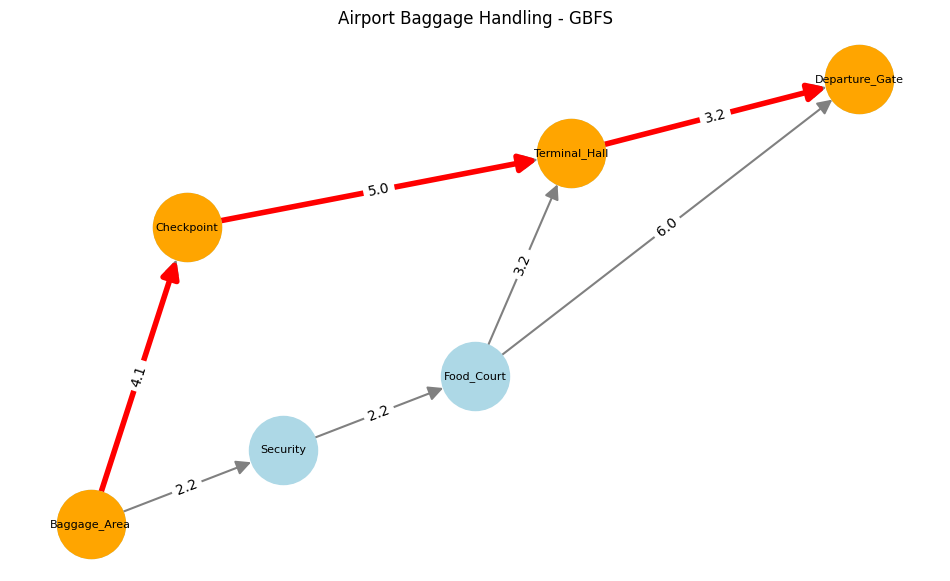

In [6]:
draw_graph(airport_graph, locations, path, "Airport Baggage Handling - GBFS")

**How the heuristic guided GBFS:** h(n) is the straight-line distance to Departure_Gate, and GBFS always expands the frontier node with the smallest h. From Baggage_Area the frontier is Security (7.81) and Checkpoint (7.28), so Checkpoint is expanded first. It leads to Terminal_Hall (3.16), which is the lowest h on the frontier, and then to Departure_Gate. GBFS ignores the edge costs already paid, so it returns Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate with cost 12.30, while the cheaper route through Security and Food_Court costs 10.40.

### Task 3: A* Search for Emergency Supply Robot

In [6]:
locations = {
    "Pharmacy": (0, 0),
    "Main_Corridor": (2, 1),
    "Patient_Wing": (1, 4),
    "Nursing_Station": (4, 2),
    "Laboratory": (5, 5),
    "Emergency_Ward": (8, 6)
}

hospital_graph = {
    "Pharmacy": {"Main_Corridor": 2.2, "Patient_Wing": 4.1},
    "Main_Corridor": {"Nursing_Station": 2.2},
    "Patient_Wing": {"Laboratory": 5.0},
    "Nursing_Station": {"Laboratory": 3.2, "Emergency_Ward": 6.0},
    "Laboratory": {"Emergency_Ward": 3.2},
    "Emergency_Ward": {}
}


def heuristic(current, goal):
    x1, y1 = locations[current]
    x2, y2 = locations[goal]
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)


def reconstruct_path(came_from, current):
    path = [current]
    while current in came_from:
        current = came_from[current]
        path.append(current)
    path.reverse()
    return path


def a_star_search(start, goal, graph):
    frontier = [(heuristic(start, goal), start)]
    came_from = {}
    g_cost = {start: 0.0}
    visited = set()
    expansion_order = []
    g_at_expansion = {}

    while frontier:
        _, current = heapq.heappop(frontier)
        if current in visited:
            continue
        visited.add(current)
        expansion_order.append(current)
        g_at_expansion[current] = g_cost[current]

        if current == goal:
            path = reconstruct_path(came_from, current)
            return path, g_cost[current], expansion_order, g_at_expansion

        for neighbor, weight in graph[current].items():
            new_g = g_cost[current] + weight
            if new_g < g_cost.get(neighbor, float("inf")):
                g_cost[neighbor] = new_g
                came_from[neighbor] = current
                heapq.heappush(frontier, (new_g + heuristic(neighbor, goal), neighbor))

    return None, float("inf"), expansion_order, g_at_expansion


start = "Pharmacy"
goal = "Emergency_Ward"

path, total_cost, expansion_order, g_cost = a_star_search(start, goal, hospital_graph)

print("A* Search")
print("--------------------------------")

print("Expansion order:")
print(" -> ".join(expansion_order))

print("\nSolution path:")
print(" -> ".join(path))

print(f"\nTotal path cost: {total_cost:.2f}")

A* Search
--------------------------------
Expansion order:
Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward

Solution path:
Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward

Total path cost: 10.40


#### g(n), h(n), f(n) table

In [7]:
print("\nA* Node Information")
print("*********************")
print(
    f"{'Node':20s}"
    f"{'g(n)':>10s}"
    f"{'h(n)':>10s}"
    f"{'f(n)':>10s}"
)

for node in expansion_order:
    g = g_cost[node]
    h = heuristic(node, goal)
    f = g + h
    print(
        f"{node:20s}"
        f"{g:10.2f}"
        f"{h:10.2f}"
        f"{f:10.2f}"
    )


A* Node Information
*********************
Node                      g(n)      h(n)      f(n)
Pharmacy                  0.00     10.00     10.00
Main_Corridor             2.20      7.81     10.01
Nursing_Station           4.40      5.66     10.06
Emergency_Ward           10.40      0.00     10.40


#### NetworkX visualization

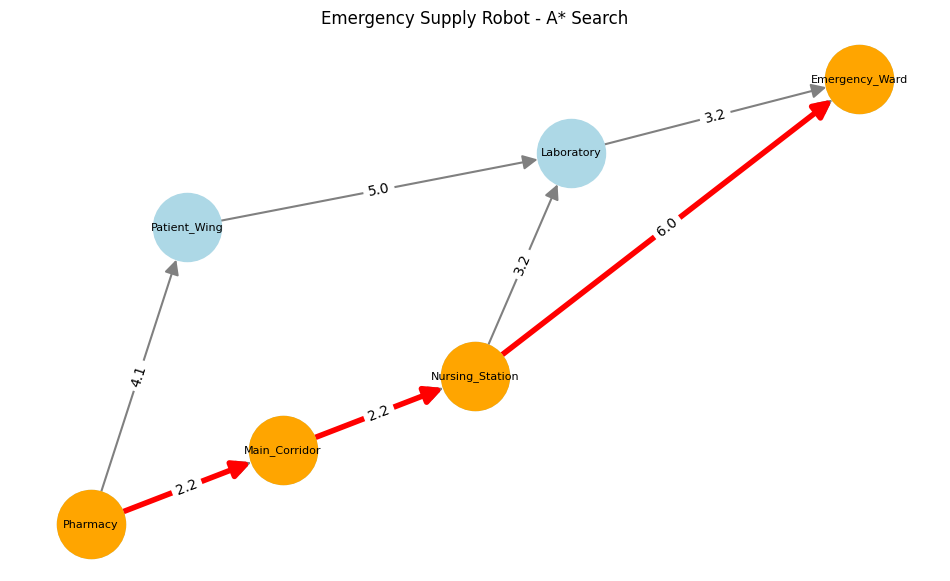

In [8]:
draw_graph(hospital_graph, locations, path, "Emergency Supply Robot - A* Search")

GBFS would primarily ask:

"Which node appears closest to the Emergency Ward?"

A* instead asks:

"Considering both the cost already travelled and the estimated remaining cost, which node has the lowest estimated total cost?"

**A* vs GBFS on this graph:** GBFS on the same graph picks Patient_Wing first (h = 7.28 < 7.81) and ends with cost 12.30. A* adds g(n): Patient_Wing has f = 4.1 + 7.28 = 11.38 while Main_Corridor has f = 2.2 + 7.81 = 10.01, so A* follows the cheaper Main_Corridor -> Nursing_Station route and finds the optimal path with cost 10.40. Considering g(n) stops the search from being lured by nodes that look close to the goal but were expensive to reach.

### Task 4: Weighted A* for Autonomous Delivery Drone

In [9]:
locations = {
    "Distribution_Center": (0, 0),
    "Zone_A": (2, 1),
    "Zone_B": (1, 4),
    "Zone_C": (4, 2),
    "Zone_D": (5, 5),
    "Customer_Building": (8, 6)
}

graph = {
    "Distribution_Center": {"Zone_A": 2.2, "Zone_B": 3.0},
    "Zone_A": {"Zone_C": 2.2},
    "Zone_B": {"Zone_D": 5.0},
    "Zone_C": {"Zone_D": 3.2, "Customer_Building": 6.0},
    "Zone_D": {"Customer_Building": 3.2},
    "Customer_Building": {}
}


def heuristic(node, goal):
    x1, y1 = locations[node]
    x2, y2 = locations[goal]
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)


goal = "Customer_Building"

heuristic_data = []
for node in locations:
    heuristic_data.append({"Node": node, "h(n)": round(heuristic(node, goal), 2)})

heuristic_df = pd.DataFrame(heuristic_data)

print("Heuristic Values:")
print(heuristic_df.to_string(index=False))


def weighted_a_star(start, goal, graph, weight):
    frontier = [(weight * heuristic(start, goal), start)]
    came_from = {}
    g_cost = {start: 0.0}
    visited = set()
    expansion_order = []

    while frontier:
        _, current = heapq.heappop(frontier)
        if current in visited:
            continue
        visited.add(current)
        expansion_order.append(current)

        if current == goal:
            path = [current]
            while path[-1] in came_from:
                path.append(came_from[path[-1]])
            path.reverse()
            return path, g_cost[current], expansion_order

        for neighbor, step in graph[current].items():
            new_g = g_cost[current] + step
            if new_g < g_cost.get(neighbor, float("inf")):
                g_cost[neighbor] = new_g
                came_from[neighbor] = current
                f = new_g + weight * heuristic(neighbor, goal)
                heapq.heappush(frontier, (f, neighbor))

    return None, float("inf"), expansion_order


start = "Distribution_Center"
goal = "Customer_Building"

weights = [1, 1.5, 2, 3]

results = []

for w in weights:
    path, cost, expansion_order = weighted_a_star(start, goal, graph, w)
    results.append({
        "Weight": w,
        "Solution Path": " → ".join(path),
        "Total Cost": round(cost, 2),
        "Nodes Expanded": len(expansion_order),
        "Expansion Order": " → ".join(expansion_order)
    })

Heuristic Values:
               Node  h(n)
Distribution_Center 10.00
             Zone_A  7.81
             Zone_B  7.28
             Zone_C  5.66
             Zone_D  3.16
  Customer_Building  0.00


In [10]:
results_df = pd.DataFrame(results)
print("Weighted A* Results")
print(results_df[["Weight", "Solution Path", "Total Cost", "Nodes Expanded"]].to_string(index=False))
results_df[["Weight", "Solution Path", "Total Cost", "Nodes Expanded"]]

Weighted A* Results
 Weight                                             Solution Path  Total Cost  Nodes Expanded
    1.0 Distribution_Center → Zone_A → Zone_C → Customer_Building        10.4               5
    1.5 Distribution_Center → Zone_A → Zone_C → Customer_Building        10.4               4
    2.0 Distribution_Center → Zone_B → Zone_D → Customer_Building        11.2               4
    3.0 Distribution_Center → Zone_B → Zone_D → Customer_Building        11.2               4


,Weight,Solution Path,Total Cost,Nodes Expanded
0,1.0,Distribution_Center → Zone_A → Zone_C → Custom...,10.4,5
1,1.5,Distribution_Center → Zone_A → Zone_C → Custom...,10.4,4
2,2.0,Distribution_Center → Zone_B → Zone_D → Custom...,11.2,4
3,3.0,Distribution_Center → Zone_B → Zone_D → Custom...,11.2,4


In [11]:
print("Detailed Expansion Orders")
print("*************************")
for row in results:
    print(f"w = {row['Weight']}: {row['Expansion Order']}")

Detailed Expansion Orders
*************************
w = 1: Distribution_Center → Zone_A → Zone_C → Zone_B → Customer_Building
w = 1.5: Distribution_Center → Zone_A → Zone_C → Customer_Building
w = 2: Distribution_Center → Zone_B → Zone_D → Customer_Building
w = 3: Distribution_Center → Zone_B → Zone_D → Customer_Building


#### NetworkX visualization

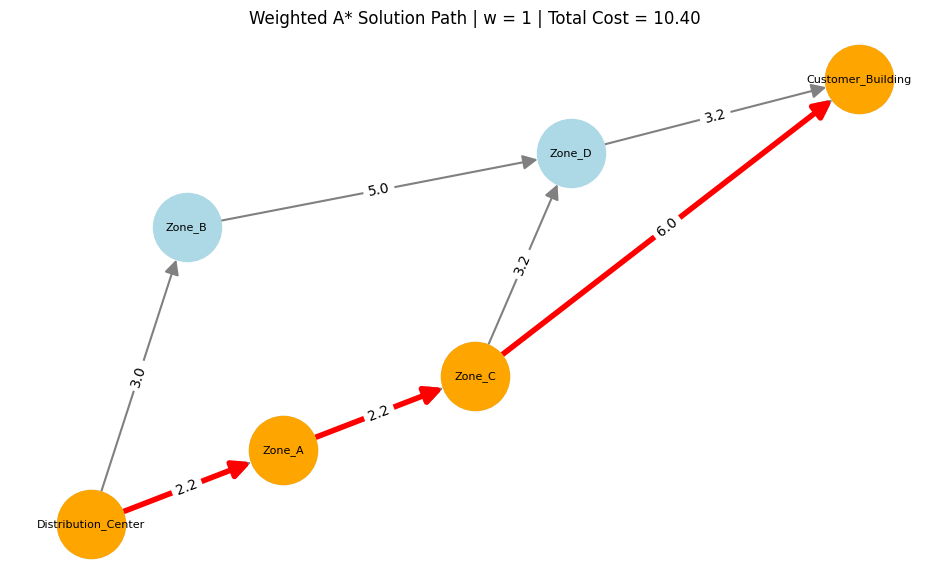

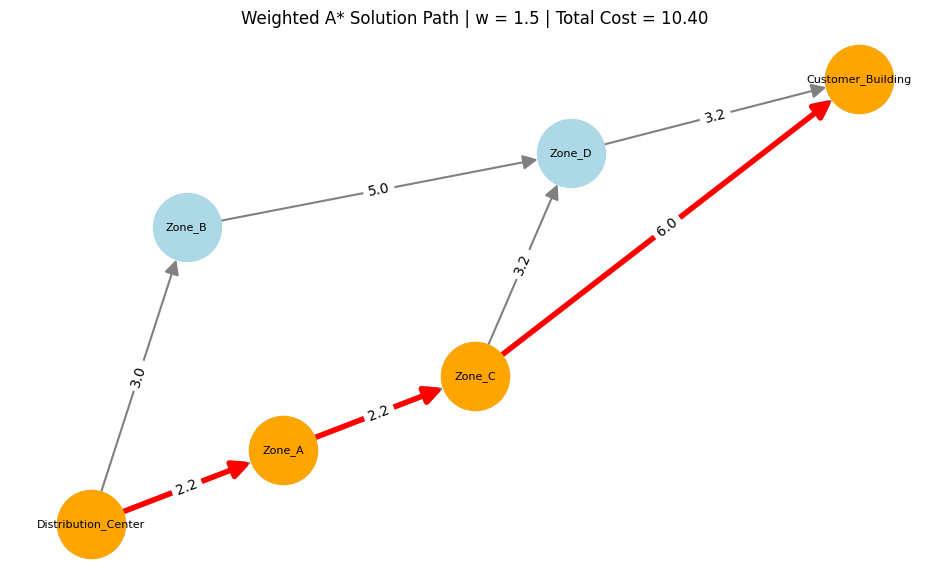

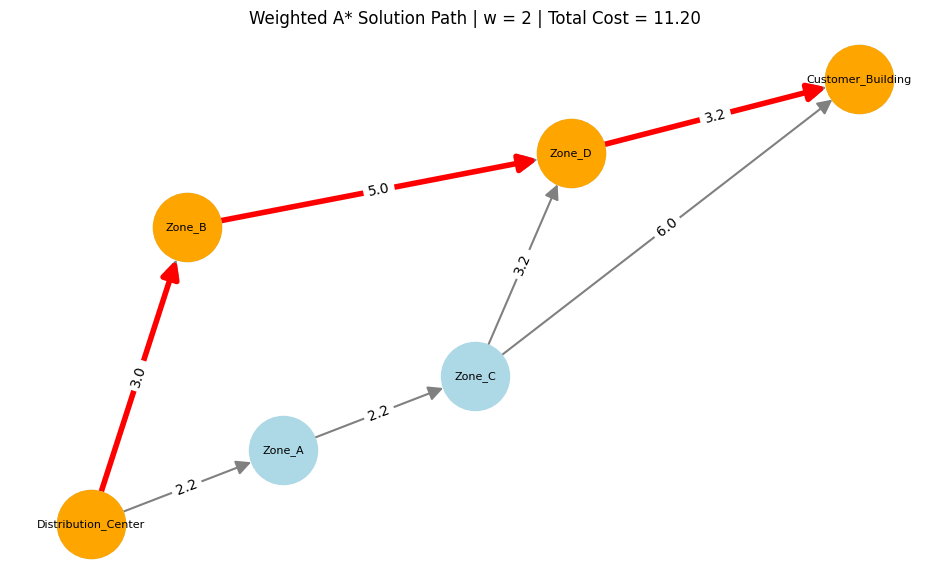

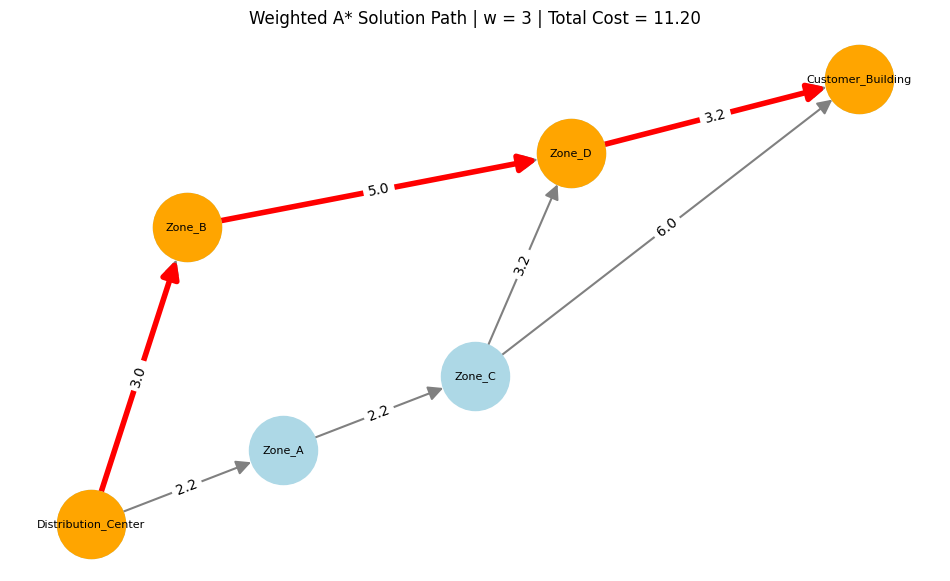

In [12]:
for w in weights:
    path, cost, expansion_order = weighted_a_star(start, goal, graph, w)
    draw_graph(
        graph, locations, path,
        f"Weighted A* Solution Path | w = {w} | Total Cost = {cost:.2f}"
    )

**Comparison.** With w = 1 and w = 1.5 the drone takes Distribution_Center -> Zone_A -> Zone_C -> Customer_Building (cost 10.4). With w = 2 and w = 3 it switches to Distribution_Center -> Zone_B -> Zone_D -> Customer_Building (cost 11.2). Nodes expanded drop from 5 (w = 1) to 4 for the larger weights, so the search does less work, but the solution gets more expensive.

**Balance of g(n) and h(n).** As w grows, the term w*h(n) dominates f(n), so the search trusts the estimate more and the real cost paid so far matters less. At w = 1 Zone_B (f = 3 + 7.28 = 10.28) is expanded before the goal (f = 10.4), which is why normal A* expands 5 nodes. At w = 1.5 the goal is reached before Zone_B is ever expanded. At w = 2 and 3 the heuristic pulls the search toward Zone_B and Zone_D, which look closer to the goal, even though that route costs more in total.

**Why w > 1 can return a costlier path.** With w > 1 the function w*h(n) can overestimate the true remaining cost, so the admissibility guarantee of A* is lost and a goal reached through a cheaper-looking f may not be the cheapest route. w = 1 is optimal; w > 1 trades optimality for speed.